In [2]:
!pip install seaborn

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [15]:
def generate_custom_r2_heatmap(csv_filename='results.csv'):
    """
    Lee un archivo CSV de resultados y genera un mapa de calor con un colormap 
    divergente personalizado: Azul para <= 0, Blanco en 0.7, Rojo intenso cerca de 1.0.
    """
    try:
        # 1. Cargar los datos
        df = pd.read_csv(csv_filename)
    except FileNotFoundError:
        print(f"Error: El archivo '{csv_filename}' no fue encontrado.")
        return
    
    # 2. Filtrar y preparar los datos
    df_folds = df[df['fold'] != 'mean'].copy()
    df_folds['fold'] = df_folds['fold'].astype(str)
    df_folds['r2'] = pd.to_numeric(df_folds['r2'])
    heatmap_data = df_folds.pivot(index='fold', columns='target', values='r2')

    # Reordenar las filas (eje Y) 
    folds_order = [str(i) for i in range(1, 11)]
    try:
        heatmap_data = heatmap_data.reindex(folds_order)
    except:
        pass # Ignorar si la reordenación falla

    
    # 3. Definir Colormap (Paleta de Colores) Personalizado

    # Rango total de visualización (incluye negativos si los hay)
    V_MIN = 0.0  # Asumimos que el valor más bajo puede ser -0.5
    V_CENTER = 0.7 # Punto donde queremos el color blanco/neutro
    V_MAX = 1.0    # Valor más alto (Rojo Intenso)

    # 3.1. Normalizar los puntos de color al rango [0.0, 1.0]
    # Necesitamos tres puntos clave: Azul (V_MIN), Blanco (V_CENTER), Rojo (V_MAX)
    # Si V_CENTER está fuera del rango [V_MIN, V_MAX], esto fallará. 
    # Asegúrate de que 0.7 esté entre V_MIN y V_MAX.
    norm_center = (V_CENTER - V_MIN) / (V_MAX - V_MIN)
    
    # Colores a usar:
    colors = [(0, 0, 1),   # Azul (RGB: 0, 0, 1) para V_MIN
              (1, 1, 1),   # Blanco (RGB: 1, 1, 1) para V_CENTER
              (1, 0, 0)]   # Rojo (RGB: 1, 0, 0) para V_MAX
    
    # Puntos de color normalizados:
    nodes = [0.0, norm_center, 1.0]

    # Crear el colormap divergente personalizado
    custom_cmap = LinearSegmentedColormap.from_list("CustomDivergingR2", list(zip(nodes, colors)))


    # 4. Generar el mapa de calor
    plt.figure(figsize=(20, 5)) 

    ax = sns.heatmap(
        heatmap_data, 
        cmap=custom_cmap, # Usamos el colormap personalizado
        vmin=0.0, 
        vmax=V_MAX,  
        cbar_kws={'label': r'$R^2$'},
        yticklabels=True,
        xticklabels=False,
        annot=True, # Muestra el valor de datos en cada celda
        fmt=".2f", # Formatea los valores a dos decimales
        annot_kws={"fontsize": 8} # Ajusta el tamaño de la fuente si es necesario
    )

    # 4.1. Rotar las anotaciones a 90 grados (Vertical)
    for text in ax.texts:
        text.set_rotation(90)
    
    # 5. Configurar etiquetas y título
    plt.ylabel('Diez Rondas', fontsize=14, labelpad=20, rotation=90)
    plt.xlabel('Proteínas Individuales', fontsize=14, labelpad=15)
    
    # Marcar algunas ticks en el eje X para referencia
    num_proteins = len(heatmap_data.columns)
    if num_proteins > 0:
        # Asegurarse de que el número de ticks no sea mayor al número de proteínas
        xticks_pos = [0, min(179, num_proteins - 1)] 
        xticks_labels = ['1', str(num_proteins)]
        plt.xticks(xticks_pos, xticks_labels, fontsize=12)

    plt.title('Mapa de Calor $R^2$ (Blanco Centrado en 0.7, Azul $le$ 0, Rojo Intenso $to$ 1.0)')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show() 

In [16]:
def calculate_global_r2_mean(csv_filename='cross_validation_results.csv'):
    """
    Calcula el promedio global de R2 leyendo los valores del CSV.
    Excluye las filas con 'fold' == 'mean' para evitar doble conteo.

    Args:
        csv_filename (str): El nombre del archivo CSV de resultados.

    Returns:
        float: El promedio global de todos los valores de R2 de los folds.
    """
    try:
        # 1. Cargar el archivo CSV
        df = pd.read_csv(csv_filename)
        
    except FileNotFoundError:
        print(f"Error: El archivo '{csv_filename}' no fue encontrado.")
        return None
    except Exception as e:
        print(f"Ocurrió un error al leer el archivo CSV: {e}")
        return None

    # 2. Filtrar los datos: Seleccionar solo las filas de los 'folds' 
    #    (Excluir la fila 'mean' si está presente, que es el promedio por proteína)
    df_folds = df[df['fold'] != 'mean'].copy()
    
    # Asegurarse de que la columna 'r2' sea numérica y manejar posibles errores
    try:
        df_folds['r2'] = pd.to_numeric(df_folds['r2'])
    except:
        print("Error: La columna 'r2' contiene valores no numéricos que no se pudieron convertir.")
        return None

    # 3. Calcular el promedio de R2 en todos los folds
    global_r2_mean = df_folds['r2'].mean()
    
    return global_r2_mean

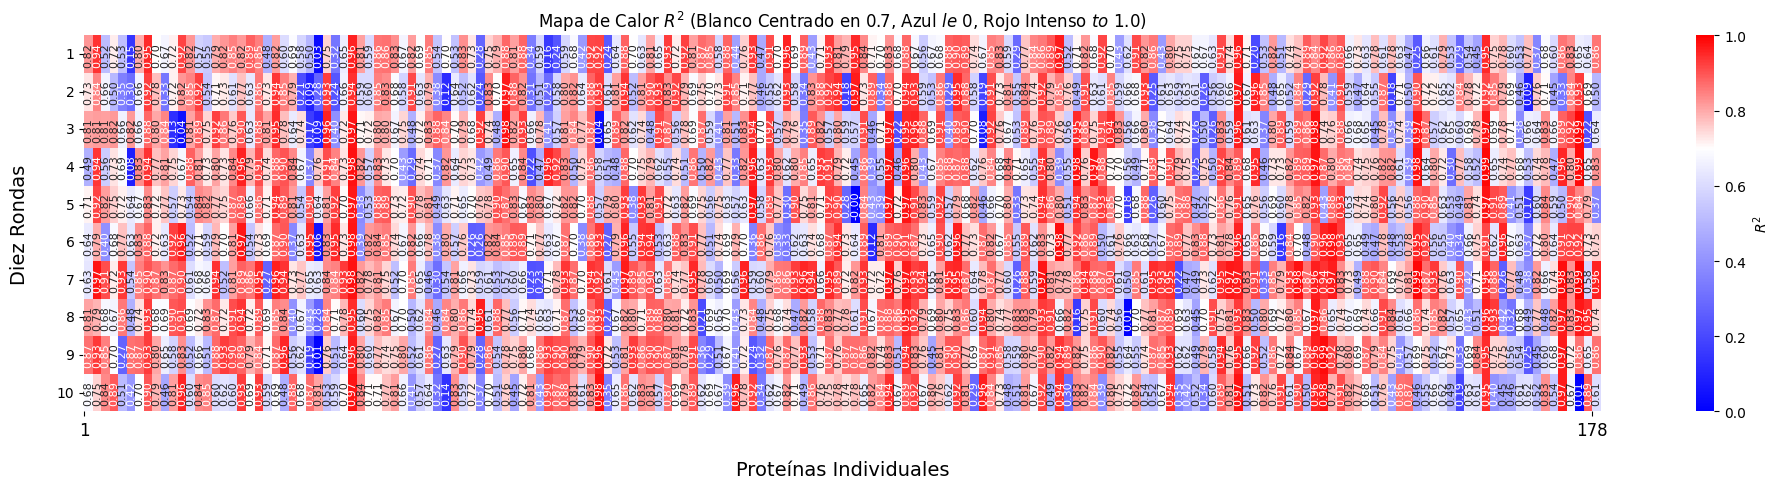

El promedio global de R2 (cross_validation_results_42_21a.csv) es: **0.7190**


In [17]:
"""
Se muestra la visuzlización del mapa de calor del cross_validation cuando se utilizan los 21 atributos
"""

file_name = 'cross_validation_results_42_21a.csv'
generate_custom_r2_heatmap(csv_filename=file_name)

mean_r2 = calculate_global_r2_mean(csv_filename=file_name)

if mean_r2 is not None:
    print(f"El promedio global de R2 ({file_name}) es: **{mean_r2:.4f}**")

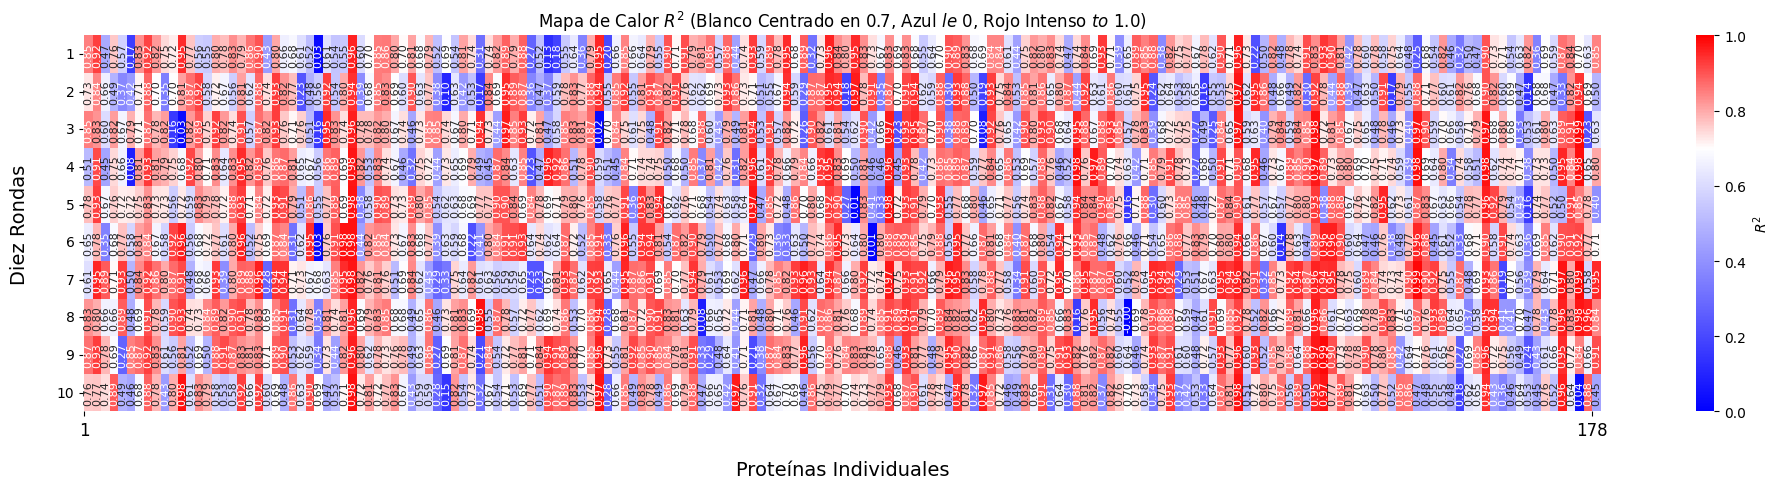

El promedio global de R2 (cross_validation_results_42_10a.csv) es: **0.7145**


In [18]:
"""
Se muestra la visuzlización del mapa de calor del cross_validation cuando se utilizan los 10 atributos
"""

file_name = 'cross_validation_results_42_10a.csv'
generate_custom_r2_heatmap(file_name)

mean_r2 = calculate_global_r2_mean(csv_filename=file_name)

if mean_r2 is not None:
    print(f"El promedio global de R2 ({file_name}) es: **{mean_r2:.4f}**")

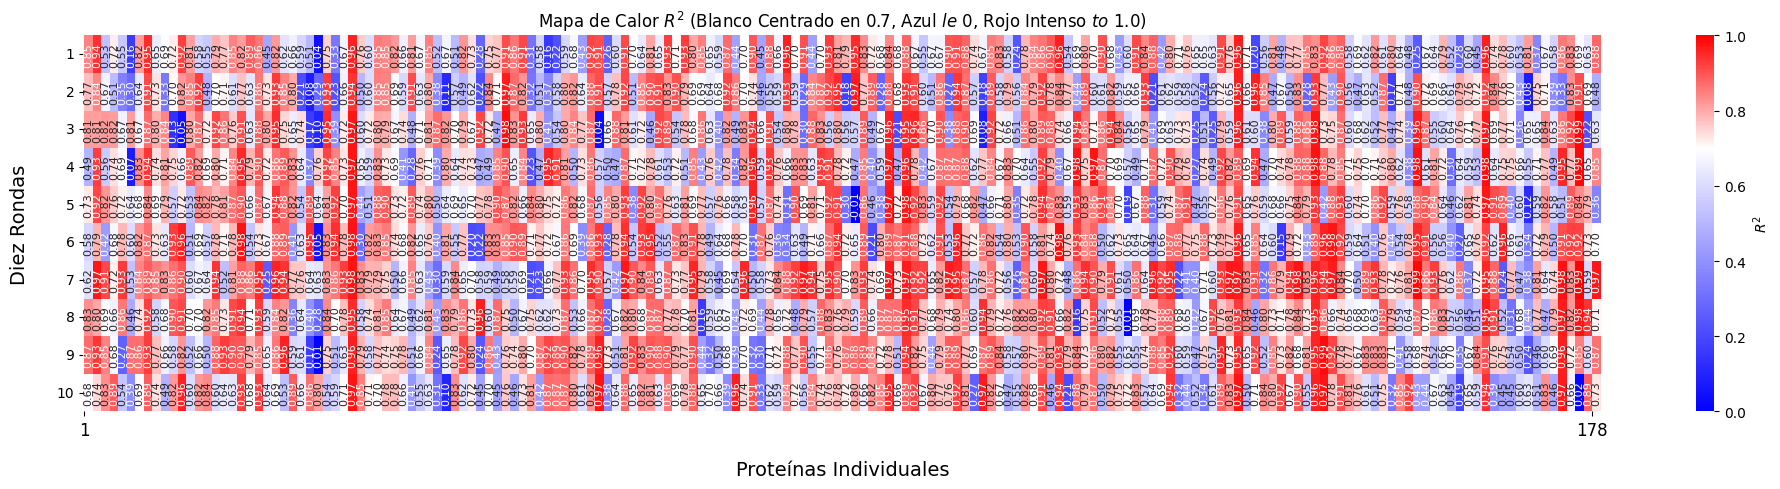

El promedio global de R2 (cross_validation_results_42_ja.csv) es: **0.7131**


In [19]:
"""
Se muestra la visuzlización del mapa de calor del cross_validation cuando se utilizan los 17 atributos que tiene el Jair
"""

file_name = 'cross_validation_results_42_ja.csv'
generate_custom_r2_heatmap(file_name)

mean_r2 = calculate_global_r2_mean(csv_filename=file_name)

if mean_r2 is not None:
    print(f"El promedio global de R2 ({file_name}) es: **{mean_r2:.4f}**")